In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as geo

In [2]:
df = pd.read_csv("puntos_examinados_clean.csv")
df.head()

,nombre,Decision,Fecha,Width,Resolution,geometry
0,URY00006,si,2025-02-13 13:52:11.656000,0.05,10,POINT (-55.3727 -34.5071)
1,URY00007,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2762 -34.391)
2,URY00008,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2061 -34.4204)
3,URY00009,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2471 -34.3791)
4,URY00010,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2317 -34.3828)


In [3]:
df["Decision"].value_counts()

Decision
si        200
no         25
dudoso     21
Name: count, dtype: int64

[]

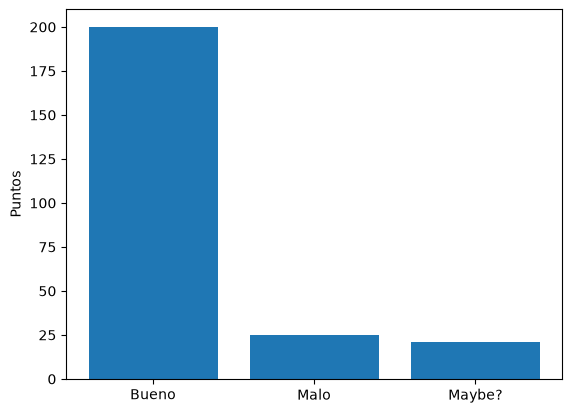

In [4]:
plt.bar(["Bueno", "Malo", "Maybe?"], df["Decision"].value_counts())
plt.ylabel("Puntos")
plt.plot()

In [5]:
# convertir a geo data frame
df_examinados = geo.GeoDataFrame(
    df,
    geometry=geo.GeoSeries.from_wkt(df["geometry"]),
    crs="EPSG:4326"
)

In [6]:
df_examinados.head()

,nombre,Decision,Fecha,Width,Resolution,geometry
0,URY00006,si,2025-02-13 13:52:11.656000,0.05,10,POINT (-55.3727 -34.5071)
1,URY00007,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2762 -34.391)
2,URY00008,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2061 -34.4204)
3,URY00009,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2471 -34.3791)
4,URY00010,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2317 -34.3828)


In [7]:
# gems params
params = pd.read_csv("../export/gemsparams.csv")
# estaciones con ids
estaciones = geo.read_file("../export/estaciones.geojson")

gems = estaciones[estaciones["type"] == "GEMS"]

In [8]:
gems.head()


,nombre,type,id,geometry
12,URY00006,GEMS,20b6e723-6bc5-052a-74da-b460cf6ac868,POINT (-55.3727 -34.5071)
13,URY00007,GEMS,412ed387-87de-b2a5-ba47-b140defba304,POINT (-55.2762 -34.391)
14,URY00008,GEMS,41d6bec1-50a4-92cc-4978-08cddf641805,POINT (-55.2061 -34.4204)
15,URY00009,GEMS,aa7c9ee0-8f8b-fd62-27d8-10926380c7f1,POINT (-55.2471 -34.3791)
16,URY00010,GEMS,7b536088-5ac4-27c1-24f6-50bec1cac49b,POINT (-55.2317 -34.3828)


In [9]:
decision_params = (df_examinados[["nombre", "Decision", "geometry"]].
       merge(gems[["nombre", "id"]], left_on="nombre", right_on="nombre", how="left").
       merge(params, left_on="id", right_on="location_id", how="left").
       drop(columns=["id", "gems_param_id", "location_id", "fecha_fin"]))
decision_params.head()

,nombre,Decision,geometry,code,fecha_inicio,value,value_cat,unit,data_quality,depth,granularidad
0,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-12 11:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
1,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-12 23:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
2,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-21 10:30:00,7.91,NaN,dimensionless,Fair,0.3,DIA
3,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-12-05 10:30:00,8.00,NaN,dimensionless,Fair,0.3,DIA
4,URY00006,si,POINT (-55.3727 -34.5071),pH,2019-01-23 11:00:00,7.59,NaN,dimensionless,Fair,0.3,DIA


In [31]:
decision_params_si = decision_params[decision_params["Decision"] == "si"]
decision_params_si.head()

,nombre,Decision,geometry,code,fecha_inicio,value,value_cat,unit,data_quality,depth,granularidad
0,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-12 11:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
1,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-12 23:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
2,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-21 10:30:00,7.91,NaN,dimensionless,Fair,0.3,DIA
3,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-12-05 10:30:00,8.00,NaN,dimensionless,Fair,0.3,DIA
4,URY00006,si,POINT (-55.3727 -34.5071),pH,2019-01-23 11:00:00,7.59,NaN,dimensionless,Fair,0.3,DIA


In [12]:
CHLA = "Chl-a"

In [33]:
chla = decision_params_si[decision_params_si["code"] == CHLA]

In [34]:
conteo_chla_si = chla.groupby("nombre").count()["code"].reset_index(name="Cant Chl-a")
print(f"Conteo total de Chl-A en 'si': {conteo_chla_si['Cant Chl-a'].sum()}")
conteo_chla_si

Conteo total de Chl-A en 'si': 3519


,nombre,Cant Chl-a
0,URY00006,1
1,URY00029,20
2,URY00031,20
3,URY00032,13
4,URY00033,22
...,...,...
130,URY00228,20
131,URY00229,22
132,URY00246,15
133,URY00249,6


In [35]:
conteo_chla_si["Cant Chl-a"].sum()

np.int64(3519)

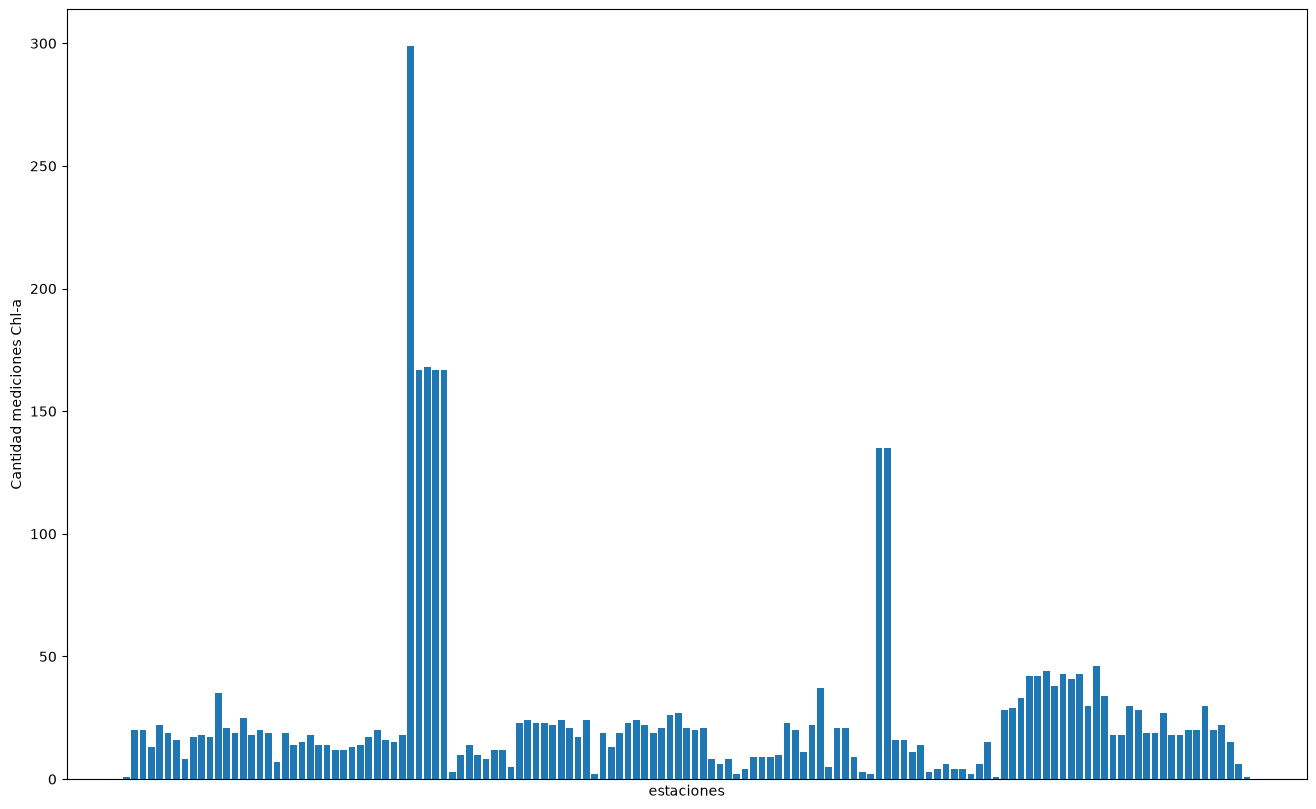

In [36]:
plt.figure(figsize=(16 ,10))
plt.bar(conteo_chla_si["nombre"], conteo_chla_si["Cant Chl-a"])
plt.xlabel("estaciones")
plt.xticks([])
plt.ylabel("Cantidad mediciones Chl-a")
plt.show()

In [37]:
MAX_MEDICIONES = conteo_chla_si["Cant Chl-a"].max()
MIN_MEDICIONES = conteo_chla_si["Cant Chl-a"].min()


In [38]:
import base64
import os

import folium
from folium.plugins import HeatMap

_LEAFLET_HEAT_JS_PATH = os.path.join(os.path.dirname(folium.__file__), "templates", "leaflet_heat.min.js")
with open(_LEAFLET_HEAT_JS_PATH, "rb") as f:
    _LEAFLET_HEAT_JS_DATA_URI = "data:text/javascript;base64," + base64.b64encode(f.read()).decode()

In [39]:
def chla_count_heatmap():
    counts_location = geo.GeoDataFrame(
        conteo_chla_si.merge(gems, on="nombre").drop(columns=["type", "id"]),
        geometry="geometry",
        crs="EPSG:4326"
    )

    heat_data = list(zip(
        counts_location.geometry.y,
        counts_location.geometry.x,
        counts_location["Cant Chl-a"]
    ))

    center = [counts_location.geometry.y.mean(), counts_location.geometry.x.mean()]

    m = folium.Map(location=center, zoom_start=7)
    heat_layer = HeatMap(heat_data, radius=20, blur=15)
    heat_layer.default_js = [("leaflet-heat.js", _LEAFLET_HEAT_JS_DATA_URI)]
    heat_layer.add_to(m)
    return m

In [40]:
chla_count_heatmap()

#### Guardan join GEMS + Chl-a

In [10]:
decision_params.head()

,nombre,Decision,geometry,code,fecha_inicio,value,value_cat,unit,data_quality,depth,granularidad
0,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-12 11:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
1,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-12 23:20:00,8.05,NaN,dimensionless,Fair,0.3,DIA
2,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-11-21 10:30:00,7.91,NaN,dimensionless,Fair,0.3,DIA
3,URY00006,si,POINT (-55.3727 -34.5071),pH,2018-12-05 10:30:00,8.00,NaN,dimensionless,Fair,0.3,DIA
4,URY00006,si,POINT (-55.3727 -34.5071),pH,2019-01-23 11:00:00,7.59,NaN,dimensionless,Fair,0.3,DIA


In [29]:
def save_joined():
    gems_chla = decision_params[decision_params["code"] == CHLA]
    gems_chla = gems_chla.drop(columns=["value_cat", "data_quality"])
    gems_chla = gems_chla.rename(columns={"fecha_inicio" : "fecha",  "code" : "param", "nombre" : "estacion"})
    gems_chla.to_file("../export/joins/gems_chla.geojson", driver="GeoJSON")

In [30]:
save_joined()